# DirVAE vs GVAE — Comparaison équitable sur DeepLesion

**Setup** : architecture identique pour les deux modèles (base=64, latent=256, ~77M params chacun).
Seule différence : le prior latent (Dirichlet vs Gaussien) et la KL associée.

**Plan** :
1. Setup & dataset
2. Modèles (architecture commune)
3. Entraînement DirVAE (10 epochs)
4. Entraînement GVAE (10 epochs)
5. Encodage du probe set
6. Évaluation : UMAP, K-Means, CLASSIX, MIG
7. Latent traversals
8. Tableau récap + discussion

## 1 — Setup & dépendances

In [41]:
!pip install pytorch-msssim umap-learn classixclustering -q

In [42]:
# ── Imports globaux ─────────────────────────────────────────────
import os, sys, time, math, random, warnings, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pytorch_msssim import ssim as ssim_fn
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ── Chemins ─────────────────────────────────────────────────────
DEEPLESION_CSV  = '/kaggle/input/datasets/kmader/nih-deeplesion-subset/DL_info.csv'
DEEPLESION_IMGS = '/kaggle/input/datasets/kmader/nih-deeplesion-subset/minideeplesion'
RESULTS_DIR     = '/kaggle/working/results'
DIRVAE_DIR      = os.path.join(RESULTS_DIR, 'DirVAE')
GVAE_DIR        = os.path.join(RESULTS_DIR, 'GVAE')
os.makedirs(DIRVAE_DIR, exist_ok=True)
os.makedirs(GVAE_DIR,   exist_ok=True)

# ── Hyperparams partagés (comparaison équitable) ────────────────
BASE        = 64
LATENT_DIM  = 256
BOTTLENECK  = 32 * BASE   # 2048 — output channels du Conv2d 8×8 de l'encoder
BATCH_SIZE  = 64
EPOCHS      = 150
LR          = 5e-5
HU_LOWER    = -1000
HU_UPPER    = 500
ALPHA_FILL  = 0.6   # Dirichlet prior concentration
BETA        = 10    # KL weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"\nHyperparams partagés (DirVAE = GVAE) :")
print(f"  base       = {BASE}")
print(f"  latent_dim = {LATENT_DIM}")
print(f"  bottleneck = {BOTTLENECK}")
print(f"  batch      = {BATCH_SIZE}")
print(f"  epochs     = {EPOCHS}")
print(f"  lr         = {LR}")

Device : cuda
GPU    : Tesla T4

Hyperparams partagés (DirVAE = GVAE) :
  base       = 64
  latent_dim = 256
  bottleneck = 2048
  batch      = 64
  epochs     = 150
  lr         = 5e-05


## 2 — Dataset DeepLesion

CSV : 32735 lésions
  [Dataset] 1124/27808 key slices trouvées (26684 absentes ignorées)
  [Dataset] 226/4927 key slices trouvées (4701 absentes ignorées)
  [Dataset] 414/9816 key slices trouvées (9402 absentes ignorées)

Train  : 1124 patches, 17 batches
Val    : 226 patches, 4 batches
Probe  : 414 patches, 7 batches


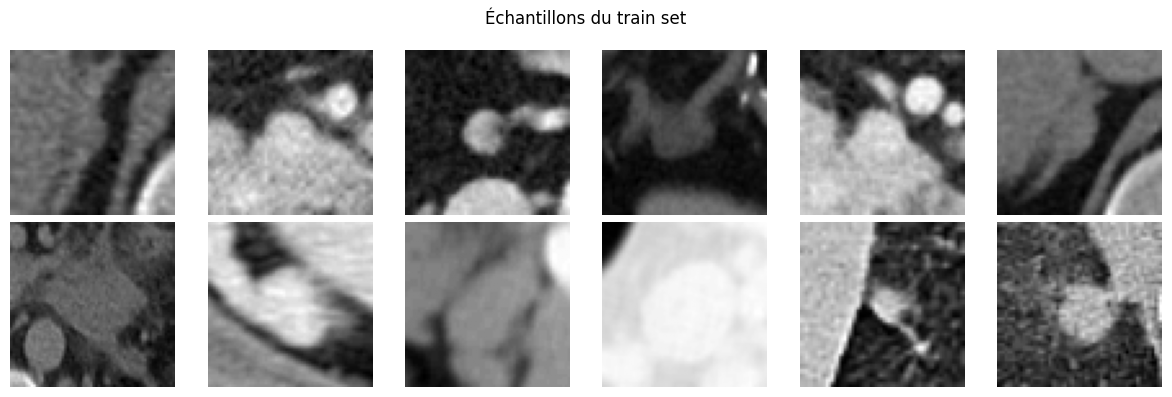

In [43]:
# ── Dataset DeepLesion (key slices uniquement, crop sur bbox) ───
HU_OFFSET = 32768

def _to_subfolder_path(file_name: str) -> str:
    if '/' in file_name or '\\' in file_name:
        return file_name.replace('\\', '/')
    folder, fname = file_name.rsplit('_', 1)
    return folder + '/' + fname

class DeepLesionDataset(Dataset):
    """Charge les key slices annotées avec crop sur bounding box."""
    def __init__(self, df, images_dir, hu_lower=-1000, hu_upper=500,
                 img_size=64, pad=10):
        self.images_dir = images_dir
        self.hu_lower = hu_lower
        self.hu_upper = hu_upper
        self.img_size = img_size
        self.pad = pad

        df = df.copy()
        df['_path'] = df['File_name'].apply(_to_subfolder_path)
        mask = df['_path'].apply(
            lambda p: os.path.exists(os.path.join(images_dir, p)))
        n_total = len(df)
        self.df = df[mask].reset_index(drop=True)
        n_kept = len(self.df)
        if n_total != n_kept:
            print(f"  [Dataset] {n_kept}/{n_total} key slices trouvées "
                  f"({n_total-n_kept} absentes ignorées)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['_path'])
        img = np.array(Image.open(img_path), dtype=np.float32) - HU_OFFSET
        img = np.clip(img, self.hu_lower, self.hu_upper)
        img = (img - self.hu_lower) / (self.hu_upper - self.hu_lower)

        # Crop sur bbox avec padding
        try:
            bbox = [float(v) for v in str(row['Bounding_boxes']).split(',')]
            x1, y1, x2, y2 = int(bbox[0]), int(bbox[1]), int(bbox[2]), int(bbox[3])
            h, w = img.shape
            x1 = max(0, x1 - self.pad); y1 = max(0, y1 - self.pad)
            x2 = min(w, x2 + self.pad); y2 = min(h, y2 + self.pad)
            patch = img[y1:y2, x1:x2]
        except Exception:
            # Fallback : crop centré
            h, w = img.shape
            cy, cx = h//2, w//2
            patch = img[cy-128:cy+128, cx-128:cx+128]

        if patch.size == 0:
            patch = img

        pil = Image.fromarray((patch * 255).astype(np.uint8))
        pil = pil.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(pil, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)

# ── Split train/val/probe ────────────────────────────────────────
df = pd.read_csv(DEEPLESION_CSV)
print(f"CSV : {len(df)} lésions")

# Train/val/probe splits
df_train = df[df['Train_Val_Test'].isin([1, 2])].copy()
df_test  = df[df['Train_Val_Test'] == 3].copy()
df_probe = df[df['Coarse_lesion_type'] != -1].copy()

train_ds = DeepLesionDataset(df_train, DEEPLESION_IMGS, HU_LOWER, HU_UPPER, 64)
val_ds   = DeepLesionDataset(df_test,  DEEPLESION_IMGS, HU_LOWER, HU_UPPER, 64)
probe_ds = DeepLesionDataset(df_probe, DEEPLESION_IMGS, HU_LOWER, HU_UPPER, 64)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
probe_loader = DataLoader(probe_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"\nTrain  : {len(train_ds)} patches, {len(train_loader)} batches")
print(f"Val    : {len(val_ds)} patches, {len(val_loader)} batches")
print(f"Probe  : {len(probe_ds)} patches, {len(probe_loader)} batches")

# Visualisation rapide
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, x in zip(axes.flat, train_ds):
    ax.imshow(x[0].numpy(), cmap='gray')
    ax.axis('off')
plt.suptitle('Échantillons du train set'); plt.tight_layout(); plt.show()

## 3 — Architecture commune

Les deux modèles partagent **exactement le même squelette** convolutif. Seul change :
- **DirVAE** : tête `alpha_fc`, reparamétrisation Dirichlet, KL Dirichlet
- **GVAE** : têtes `mu_fc` + `logvar_fc`, reparam gaussienne, KL forme fermée

In [60]:
# ── Blocs de base ───────────────────────────────────────────────
class Conv(nn.Module):
    def __init__(self, in_c, out_c, k, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, stride, padding, bias=False),
            nn.GELU(), nn.BatchNorm2d(out_c))
    def forward(self, x): return self.conv(x)

class ConvTranspose(nn.Module):
    def __init__(self, in_c, out_c, k, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, k, stride, padding, bias=False),
            nn.GELU(), nn.BatchNorm2d(out_c))
    def forward(self, x): return self.conv(x)

class ConvUpsampling(nn.Module):
    def __init__(self, in_c, out_c, k, stride=1, padding=0):
        super().__init__()
        self.scale_factor = k
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, stride, padding, bias=False),
            nn.GELU(), nn.BatchNorm2d(out_c))
    def forward(self, x):
        x = F.interpolate(x, scale_factor=self.scale_factor,
                          mode='bilinear', align_corners=False)
        return self.conv(x)

# ── Encoder commun ──────────────────────────────────────────────
def make_encoder(base, latent_dim, bottleneck):
    b = base
    return nn.Sequential(
        Conv(1,    b,   3, padding=1),                  # 64×64
        Conv(b,    2*b, 3, stride=2, padding=1),        # 32×32
        Conv(2*b,  2*b, 3, padding=1),
        Conv(2*b,  2*b, 3, stride=2, padding=1),        # 16×16
        Conv(2*b,  4*b, 3, padding=1),
        Conv(4*b,  4*b, 3, stride=2, padding=1),        # 8×8
        Conv(4*b,  4*b, 3, padding=1),
        nn.Conv2d(4*b, bottleneck, 8),                  # 1×1
        nn.GELU(),
        nn.Flatten(),
        nn.Linear(bottleneck, latent_dim, bias=False),
        nn.BatchNorm1d(latent_dim, momentum=0.9),
        nn.GELU(),
    )

# ── Decoder commun ──────────────────────────────────────────────
def make_decoder(base, latent_dim, bottleneck):
    b = base
    return nn.Sequential(
        nn.Linear(latent_dim, bottleneck, bias=False),
        nn.BatchNorm1d(bottleneck, momentum=0.9),
        nn.GELU(),
        nn.Unflatten(1, (bottleneck, 1, 1)),
        nn.Conv2d(bottleneck, bottleneck, 1),
        ConvTranspose(bottleneck, 4*b, 8),                   # 8×8
        Conv(4*b, 4*b, 3, padding=1),
        ConvUpsampling(4*b, 4*b, 4, stride=2, padding=1),    # 16×16
        Conv(4*b, 2*b, 3, padding=1),
        ConvUpsampling(2*b, 2*b, 4, stride=2, padding=1),    # 32×32
        Conv(2*b, b, 3, padding=1),
        ConvUpsampling(b, b, 4, stride=2, padding=1),        # 64×64
        nn.Conv2d(b, 1, 3, padding=1),
        nn.Sigmoid(),
    )

# ── DirVAE ──────────────────────────────────────────────────────
class DirVAE(nn.Module):
    """DirVAE avec KL annealing + softplus saturé pour éviter le collapse."""
    def __init__(self, base=BASE, latent_dim=LATENT_DIM,
                 bottleneck=BOTTLENECK, alpha_fill=ALPHA_FILL):
        super().__init__()
        self.latent_dim = latent_dim
        self.alpha_fill = alpha_fill
        self.encoder  = make_encoder(base, latent_dim, bottleneck)
        self.alpha_fc = nn.Linear(latent_dim, latent_dim)
        self.decoder  = make_decoder(base, latent_dim, bottleneck)

    def reparameterize(self, alpha_logits):
        # Clip pour stabilité numérique + min plus haut pour éviter collapse
        alpha_logits = torch.clamp(alpha_logits, -10, 10)
        alpha = F.softplus(alpha_logits) + 0.5     # min α=0.5 (était 1e-4)
        dist = torch.distributions.Dirichlet(alpha)
        return dist.rsample(), alpha

    def forward(self, x):
        h = self.encoder(x)
        alpha_logits = self.alpha_fc(h)
        z, alpha = self.reparameterize(alpha_logits)
        return self.decoder(z), alpha, z

    def kl_divergence(self, alpha):
        prior = torch.full_like(alpha, self.alpha_fill)
        a0 = alpha.sum(-1, keepdim=True)
        p0 = prior.sum(-1, keepdim=True)
        kl = (torch.lgamma(a0) - torch.lgamma(p0)
              - torch.lgamma(alpha).sum(-1, keepdim=True)
              + torch.lgamma(prior).sum(-1, keepdim=True)
              + ((alpha - prior) *
                 (torch.digamma(alpha) - torch.digamma(a0))).sum(-1, keepdim=True))
        return kl.squeeze(-1)

# ── Gaussian VAE ────────────────────────────────────────────────
class GVAE(nn.Module):
    def __init__(self, base=BASE, latent_dim=LATENT_DIM, bottleneck=BOTTLENECK):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder   = make_encoder(base, latent_dim, bottleneck)
        self.mu_fc     = nn.Linear(latent_dim, latent_dim)
        self.logvar_fc = nn.Linear(latent_dim, latent_dim)
        self.decoder   = make_decoder(base, latent_dim, bottleneck)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu_fc(h), self.logvar_fc(h)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar, z

    def kl_divergence(self, mu, logvar):
        return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)

# ── Vérif # params ──────────────────────────────────────────────
def n_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

dir_test  = DirVAE()
gvae_test = GVAE()
print(f"DirVAE params : {n_params(dir_test):,}")
print(f"GVAE   params : {n_params(gvae_test):,}")
print(f"\n→ Architectures équivalentes (la diff vient des têtes mu/logvar dans GVAE)")
del dir_test, gvae_test

DirVAE params : 76,610,049
GVAE   params : 76,675,841

→ Architectures équivalentes (la diff vient des têtes mu/logvar dans GVAE)


## 4 — Boucle d'entraînement générique

In [62]:
# ── Fonction d'entraînement partagée ────────────────────────────
def compute_loss(model, x, x_hat, kl, beta, batch_size):
    """Loss = L1 recon + (1-α) SSIM + β·KL."""
    l1 = F.l1_loss(x_hat, x, reduction='sum') / batch_size
    ssim_val = ssim_fn(x_hat, x, data_range=1.0)
    ssim_loss = 1 - ssim_val
    recon = 0.5 * l1 + 0.5 * ssim_loss
    kl_mean = kl.mean()
    loss = recon + beta * kl_mean
    return loss, recon, kl_mean, ssim_val

def train_one_epoch(model, loader, optimizer, model_type, beta, epoch):
    model.train()
    losses, recons, kls, ssims = [], [], [], []
    for batch_idx, x in enumerate(loader):
        x = x.to(device, non_blocking=True)
        bs = x.size(0)
        optimizer.zero_grad()

        if model_type == 'dirvae':
            x_hat, alpha, z = model(x)
            kl = model.kl_divergence(alpha)
        else:
            x_hat, mu, logvar, z = model(x)
            kl = model.kl_divergence(mu, logvar)

        loss, recon, kl_mean, ssim_val = compute_loss(model, x, x_hat, kl, beta, bs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        losses.append(loss.item())
        recons.append(recon.item())
        kls.append(kl_mean.item())
        ssims.append(ssim_val.item())

        if batch_idx % 50 == 0:
            print(f"  [{batch_idx:4d}/{len(loader)}] "
                  f"loss={loss.item():.3f}  recon={recon.item():.3f}  "
                  f"kl={kl_mean.item():.3f}  ssim={ssim_val.item():.3f}")
    return np.mean(losses), np.mean(recons), np.mean(kls), np.mean(ssims)

@torch.no_grad()
def evaluate(model, loader, model_type, beta):
    model.eval()
    losses, recons, ssims = [], [], []
    for x in loader:
        x = x.to(device, non_blocking=True)
        bs = x.size(0)
        if model_type == 'dirvae':
            x_hat, alpha, z = model(x)
            kl = model.kl_divergence(alpha)
        else:
            x_hat, mu, logvar, z = model(x)
            kl = model.kl_divergence(mu, logvar)
        loss, recon, _, ssim_val = compute_loss(model, x, x_hat, kl, beta, bs)
        losses.append(loss.item()); recons.append(recon.item()); ssims.append(ssim_val.item())
    return np.mean(losses), np.mean(recons), np.mean(ssims)

def fit(model, model_type, train_loader, val_loader, epochs, lr, beta_max, save_dir):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    history = {'train_loss': [], 'train_recon': [], 'train_kl': [], 'train_ssim': [],
               'val_loss': [], 'val_recon': [], 'val_ssim': []}

    for epoch in range(1, epochs+1):
        # KL annealing : β monte de 0 à beta_max sur les 50% premières epochs
        beta = beta_max * min(1.0, epoch / max(1, epochs // 2))
        print(f"\n— Epoch {epoch}/{epochs} (β={beta:.2f}) —")
        tl, tr, tk, ts = train_one_epoch(model, train_loader, optimizer,
                                          model_type, beta, epoch)
        vl, vr, vs = evaluate(model, val_loader, model_type, beta)
        scheduler.step(vl)
        history['train_loss'].append(tl); history['train_recon'].append(tr)
        history['train_kl'].append(tk);   history['train_ssim'].append(ts)
        history['val_loss'].append(vl);   history['val_recon'].append(vr)
        history['val_ssim'].append(vs)
        print(f"  train recon={tr:.3f} kl={tk:.3f} ssim={ts:.3f}")
        print(f"  val   recon={vr:.3f} ssim={vs:.3f}")

    torch.save({'model_state_dict': model.state_dict(), 'history': history,
                'config': {'base': BASE, 'latent_dim': LATENT_DIM, 
                           'bottleneck': BOTTLENECK}},
               os.path.join(save_dir, 'checkpoint.pt'))
    return history

## 5 — Entraînement DirVAE


— Epoch 1/150 (β=0.13) —
  [   0/17] loss=463.105  recon=458.516  kl=34.417  ssim=0.182
  train recon=311.900 kl=35.464 ssim=0.391
  val   recon=296.026 ssim=0.659

— Epoch 2/150 (β=0.27) —
  [   0/17] loss=212.963  recon=203.253  kl=36.411  ssim=0.554
  train recon=197.706 kl=36.933 ssim=0.607
  val   recon=261.499 ssim=0.661

— Epoch 3/150 (β=0.40) —
  [   0/17] loss=179.193  recon=164.233  kl=37.401  ssim=0.675
  train recon=179.510 kl=37.736 ssim=0.628
  val   recon=257.656 ssim=0.661

— Epoch 4/150 (β=0.53) —
  [   0/17] loss=199.543  recon=179.168  kl=38.203  ssim=0.637
  train recon=173.036 kl=38.260 ssim=0.635
  val   recon=172.369 ssim=0.662

— Epoch 5/150 (β=0.67) —
  [   0/17] loss=216.746  recon=191.122  kl=38.437  ssim=0.601
  train recon=163.402 kl=38.559 ssim=0.643
  val   recon=157.799 ssim=0.658

— Epoch 6/150 (β=0.80) —
  [   0/17] loss=187.545  recon=156.821  kl=38.405  ssim=0.654
  train recon=162.949 kl=38.499 ssim=0.648
  val   recon=154.117 ssim=0.662

— Epoch 7

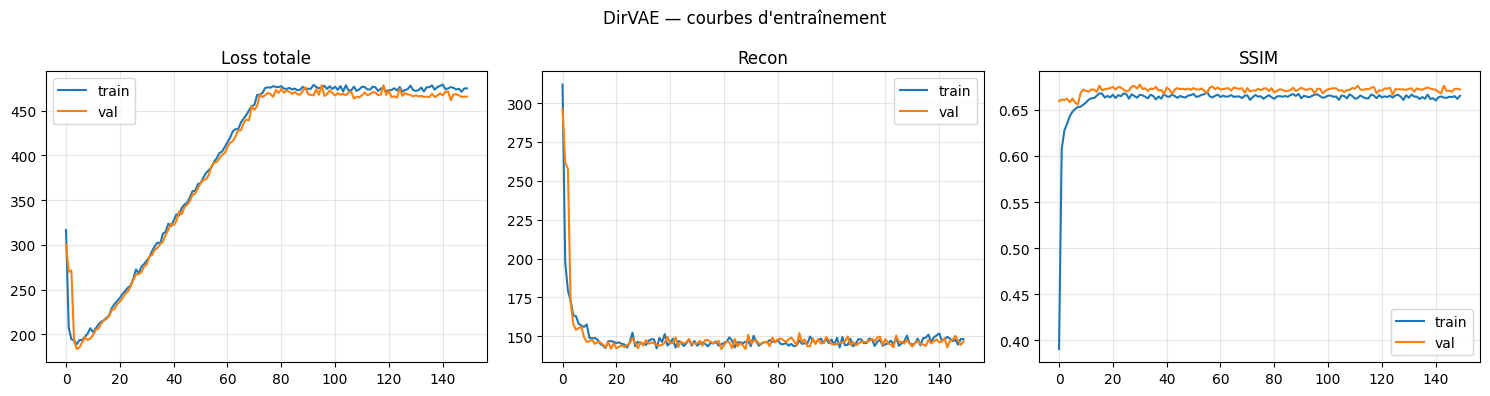

In [65]:
dirvae_model = DirVAE().to(device)
dir_history = fit(dirvae_model, 'dirvae', train_loader, val_loader,
                  EPOCHS, LR, BETA, DIRVAE_DIR)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(dir_history['train_loss'], label='train'); axes[0].plot(dir_history['val_loss'], label='val')
axes[0].set_title('Loss totale'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(dir_history['train_recon'], label='train'); axes[1].plot(dir_history['val_recon'], label='val')
axes[1].set_title('Recon'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(dir_history['train_ssim'], label='train'); axes[2].plot(dir_history['val_ssim'], label='val')
axes[2].set_title('SSIM'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('DirVAE — courbes d\'entraînement'); plt.tight_layout()
plt.savefig(os.path.join(DIRVAE_DIR, 'curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6 — Entraînement GVAE


════════════════════════════════════════════════════════════
  Training GVAE for 150 epochs
════════════════════════════════════════════════════════════

— Epoch 1/150 —
  [   0/17] loss=837.059  recon=519.784  kl=31.728  ssim=0.176
  train_loss=437.008 recon=311.884 kl=12.512 ssim=0.380
  val_loss  =349.842 recon=309.219 ssim=0.658

— Epoch 2/150 —
  [   0/17] loss=309.761  recon=235.670  kl=7.409  ssim=0.544
  train_loss=284.204 recon=224.591 kl=5.961 ssim=0.587
  val_loss  =287.556 recon=264.337 ssim=0.659

— Epoch 3/150 —
  [   0/17] loss=296.994  recon=247.579  kl=4.941  ssim=0.621
  train_loss=263.161 recon=221.340 kl=4.182 ssim=0.610
  val_loss  =245.790 recon=215.853 ssim=0.654

— Epoch 4/150 —
  [   0/17] loss=297.726  recon=244.865  kl=5.286  ssim=0.585
  train_loss=246.186 recon=210.645 kl=3.554 ssim=0.620
  val_loss  =235.155 recon=198.521 ssim=0.633

— Epoch 5/150 —
  [   0/17] loss=231.243  recon=200.310  kl=3.093  ssim=0.641
  train_loss=241.364 recon=212.290 kl=2.907 s

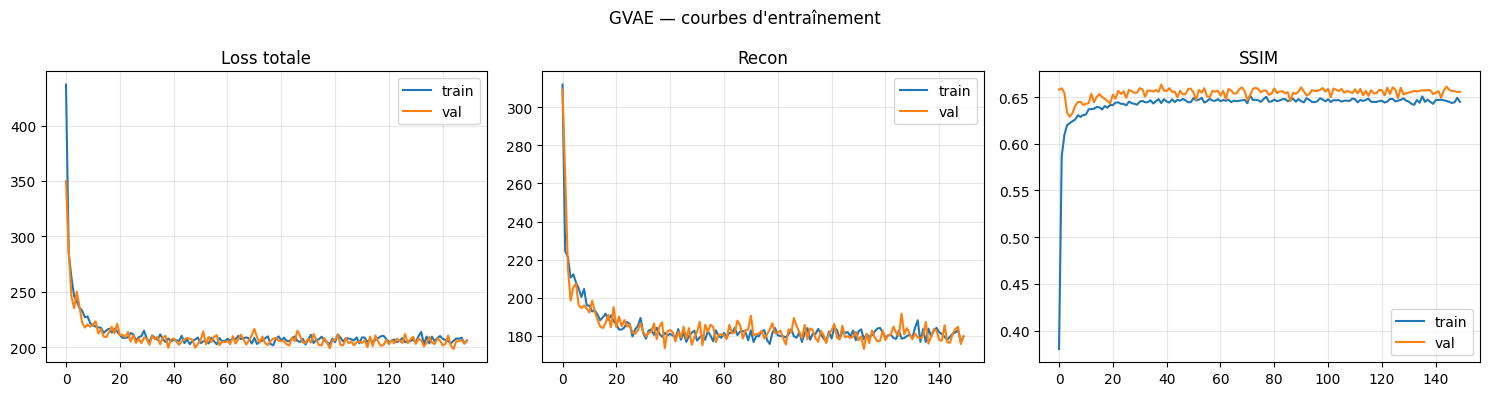

In [47]:
gvae_model = GVAE().to(device)
gv_history = fit(gvae_model, 'gvae', train_loader, val_loader,
                 EPOCHS, LR, BETA, GVAE_DIR)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(gv_history['train_loss'], label='train'); axes[0].plot(gv_history['val_loss'], label='val')
axes[0].set_title('Loss totale'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(gv_history['train_recon'], label='train'); axes[1].plot(gv_history['val_recon'], label='val')
axes[1].set_title('Recon'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(gv_history['train_ssim'], label='train'); axes[2].plot(gv_history['val_ssim'], label='val')
axes[2].set_title('SSIM'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.suptitle('GVAE — courbes d\'entraînement'); plt.tight_layout()
plt.savefig(os.path.join(GVAE_DIR, 'curves.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7 — Encodage du probe set

On extrait les latents (alpha pour DirVAE, mu pour GVAE) sur le probe set
+ labels organe pour les analyses suivantes.

In [66]:
@torch.no_grad()
def encode_probe(model, loader, model_type):
    model.eval()
    latents = []
    for x in loader:
        x = x.to(device, non_blocking=True)
        h = model.encoder(x)
        if model_type == 'dirvae':
            z = model.alpha_fc(h)
        else:
            z = model.mu_fc(h)
        latents.append(z.cpu().numpy())
    return np.concatenate(latents, axis=0)

latents_dirvae = encode_probe(dirvae_model, probe_loader, 'dirvae')
latents_gvae   = encode_probe(gvae_model,   probe_loader, 'gvae')

# Labels alignés sur le df filtré du dataset
organ_labels = probe_ds.df['Coarse_lesion_type'].values.astype(int)
malig_labels = (probe_ds.df['possibly_noisy'].values.astype(int)
                if 'possibly_noisy' in probe_ds.df.columns
                else np.zeros(len(probe_ds.df), dtype=int))

print(f"latents_dirvae : {latents_dirvae.shape}")
print(f"latents_gvae   : {latents_gvae.shape}")
print(f"organ_labels   : {organ_labels.shape}, uniques = {sorted(np.unique(organ_labels))}")

assert len(latents_dirvae) == len(latents_gvae) == len(organ_labels), \
    "Mismatch entre latents et labels !"

# Sauvegarde
np.save(os.path.join(RESULTS_DIR, 'latents_dirvae.npy'), latents_dirvae)
np.save(os.path.join(RESULTS_DIR, 'latents_gvae.npy'),   latents_gvae)
np.save(os.path.join(RESULTS_DIR, 'probe_organ.npy'),    organ_labels)
np.save(os.path.join(RESULTS_DIR, 'probe_malig.npy'),    malig_labels)
print(f"\n✅ Latents sauvegardés dans {RESULTS_DIR}")

latents_dirvae : (414, 256)
latents_gvae   : (414, 256)
organ_labels   : (414,), uniques = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

✅ Latents sauvegardés dans /kaggle/working/results


## 8 — UMAP 2D : visualisation comparative

Fit UMAP DirVAE...
Fit UMAP GVAE...


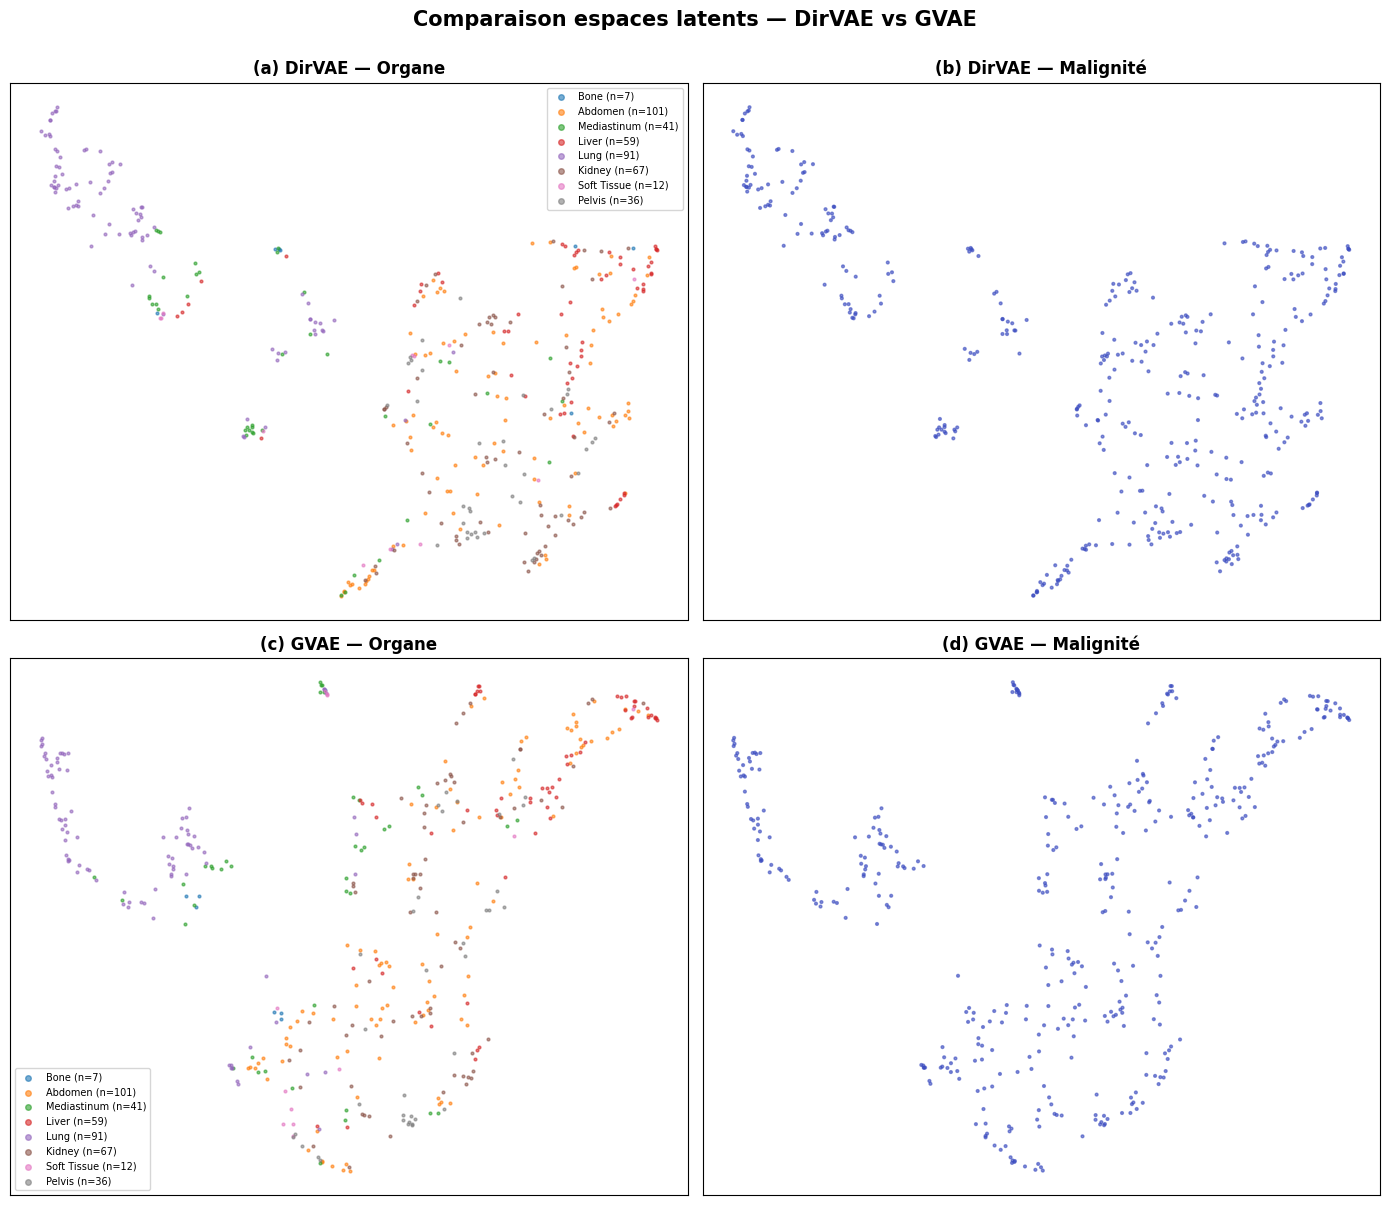

In [67]:
import umap

print("Fit UMAP DirVAE...")
emb_dirvae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                       random_state=SEED).fit_transform(latents_dirvae)
print("Fit UMAP GVAE...")
emb_gvae = umap.UMAP(n_neighbors=15, min_dist=0.1,
                     random_state=SEED).fit_transform(latents_gvae)

np.save(os.path.join(RESULTS_DIR, 'emb_dirvae.npy'), emb_dirvae)
np.save(os.path.join(RESULTS_DIR, 'emb_gvae.npy'),   emb_gvae)

organ_names = {-1:'Unknown', 1:'Bone', 2:'Abdomen', 3:'Mediastinum',
               4:'Liver', 5:'Lung', 6:'Kidney', 7:'Soft Tissue', 8:'Pelvis'}

# ── Panel 2×2 : DirVAE vs GVAE × organe vs malignité ────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
unique_organs = sorted(np.unique(organ_labels))
cmap_organ = plt.cm.tab10

def panel_organ(ax, emb, title):
    for i, org in enumerate(unique_organs):
        mask = organ_labels == org
        if mask.sum() < 5: continue
        ax.scatter(emb[mask, 0], emb[mask, 1], s=4, alpha=0.6,
                   color=cmap_organ(i % 10),
                   label=f"{organ_names.get(org, str(org))} (n={mask.sum()})")
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=7, loc='best', markerscale=2)

def panel_malig(ax, emb, title):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=malig_labels,
                    cmap='coolwarm', s=4, alpha=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

panel_organ(axes[0, 0], emb_dirvae, '(a) DirVAE — Organe')
panel_malig(axes[0, 1], emb_dirvae, '(b) DirVAE — Malignité')
panel_organ(axes[1, 0], emb_gvae,   '(c) GVAE — Organe')
panel_malig(axes[1, 1], emb_gvae,   '(d) GVAE — Malignité')

fig.suptitle('Comparaison espaces latents — DirVAE vs GVAE',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'key_figure_umap.png'),
            dpi=130, bbox_inches='tight')
plt.show()

## 9 — Clustering : K-Means + CLASSIX

In [68]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score, adjusted_mutual_info_score,
    adjusted_rand_score)

def cluster_purity(y_true, y_pred):
    contingency = pd.crosstab(y_pred, y_true)
    return contingency.max(axis=1).sum() / contingency.values.sum()

# ── K-Means ─────────────────────────────────────────────────────
n_organs = len(np.unique(organ_labels))
km_results = []
for name, lat in [('DirVAE', latents_dirvae), ('GVAE', latents_gvae)]:
    for k, gt, fname in [(n_organs, organ_labels, 'organe'),
                          (2, malig_labels, 'malignité')]:
        if len(np.unique(gt)) < 2: continue
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(lat)
        km_results.append({
            'modèle': name, 'facteur': fname, 'k': k,
            'NMI': normalized_mutual_info_score(gt, km.labels_),
            'AMI': adjusted_mutual_info_score(gt, km.labels_),
            'ARI': adjusted_rand_score(gt, km.labels_),
            'pureté': cluster_purity(gt, km.labels_),
        })

df_km = pd.DataFrame(km_results)
print("═"*60); print("  K-MEANS"); print("═"*60)
print(df_km.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
df_km.to_csv(os.path.join(RESULTS_DIR, 'kmeans_metrics.csv'), index=False)

════════════════════════════════════════════════════════════
  K-MEANS
════════════════════════════════════════════════════════════
modèle facteur  k    NMI    AMI    ARI  pureté
DirVAE  organe  8 0.3735 0.3498 0.1840  0.4807
  GVAE  organe  8 0.3350 0.3084 0.1330  0.4469


In [51]:
# ── CLASSIX (avec sweep de radius) ──────────────────────────────
from classix import CLASSIX

def fit_classix_sweep(lat, gt, radii=(0.15, 0.3, 0.5, 0.8, 1.2, 2.0)):
    rows = []
    best = {'nmi': -1, 'radius': None, 'labels': None, 'n_clusters': 0}
    for r in radii:
        try:
            clx = CLASSIX(sorting='pca', radius=r, verbose=0).fit(lat)
            labels = clx.labels_
            valid = labels >= 0
            n_clu = len(np.unique(labels[valid])) if valid.sum() > 0 else 0
            n_out = int((labels == -1).sum())
            if n_clu < 2:
                rows.append({'radius': r, 'n_clusters': n_clu,
                             'n_outliers': n_out, 'NMI': np.nan,
                             'AMI': np.nan, 'pureté': np.nan})
                continue
            nmi = normalized_mutual_info_score(gt[valid], labels[valid])
            ami = adjusted_mutual_info_score(gt[valid], labels[valid])
            pur = cluster_purity(gt[valid], labels[valid])
            rows.append({'radius': r, 'n_clusters': n_clu, 'n_outliers': n_out,
                         'NMI': nmi, 'AMI': ami, 'pureté': pur})
            if nmi > best['nmi']:
                best.update({'nmi': nmi, 'radius': r,
                             'labels': labels, 'n_clusters': n_clu})
        except Exception as e:
            rows.append({'radius': r, 'error': str(e)[:50]})
    return pd.DataFrame(rows), best

clx_results = []
print("\n═══ CLASSIX DirVAE (cible : organe) ═══")
df_d, best_d = fit_classix_sweep(latents_dirvae, organ_labels)
print(df_d.to_string(index=False))
print(f"  → meilleur : radius={best_d['radius']}, "
      f"{best_d['n_clusters']} clusters, NMI={best_d['nmi']:.4f}")

print("\n═══ CLASSIX GVAE (cible : organe) ═══")
df_g, best_g = fit_classix_sweep(latents_gvae, organ_labels)
print(df_g.to_string(index=False))
print(f"  → meilleur : radius={best_g['radius']}, "
      f"{best_g['n_clusters']} clusters, NMI={best_g['nmi']:.4f}")

df_d['modèle'] = 'DirVAE'; df_g['modèle'] = 'GVAE'
df_classix = pd.concat([df_d, df_g], ignore_index=True)
df_classix.to_csv(os.path.join(RESULTS_DIR, 'classix_metrics.csv'), index=False)


═══ CLASSIX DirVAE (cible : organe) ═══
 radius  n_clusters  n_outliers      NMI      AMI   pureté
   0.15         111           0 0.369376 0.137029 0.536232
   0.30          65           0 0.309927 0.143167 0.473430
   0.50          44           0 0.282810 0.153748 0.444444
   0.80          24           0 0.296366 0.221082 0.444444
   1.20           1           0      NaN      NaN      NaN
   2.00           1           0      NaN      NaN      NaN
  → meilleur : radius=0.15, 111 clusters, NMI=0.3694

═══ CLASSIX GVAE (cible : organe) ═══
 radius  n_clusters  n_outliers      NMI      AMI   pureté
   0.15         127           0 0.400592 0.159008 0.572464
   0.30          90           0 0.383573 0.194550 0.533816
   0.50          58           0 0.329415 0.185189 0.483092
   0.80          29           0 0.286515 0.193778 0.439614
   1.20           3           0 0.047675 0.032992 0.260870
   2.00           1           0      NaN      NaN      NaN
  → meilleur : radius=0.15, 127 clusters,

## 10 — MIG (Mutual Information Gap)

════════════════════════════════════════════════════════════
  MIG SCORE
════════════════════════════════════════════════════════════
modèle facteur    MIG  top_dim  top_MI  second_MI
DirVAE  organe 0.0128       51  0.6837     0.6599
  GVAE  organe 0.0169      238  0.7757     0.7442


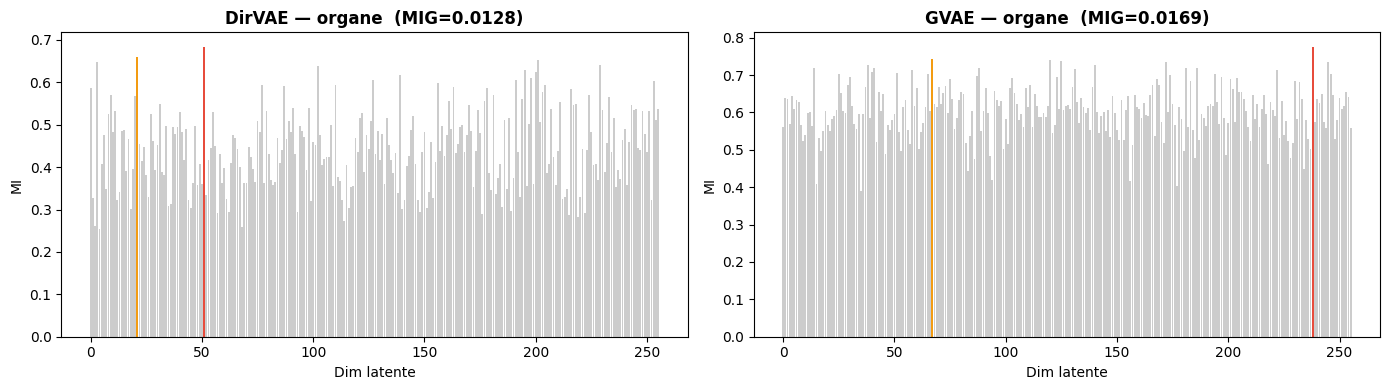

In [69]:
from sklearn.metrics import mutual_info_score

def discrete_entropy(y):
    _, c = np.unique(y, return_counts=True)
    p = c / c.sum()
    return -np.sum(p * np.log(p + 1e-12))

def mig_score(latents, factor, n_bins=20):
    factor = np.asarray(factor)
    if len(np.unique(factor)) < 2:
        return np.nan, np.zeros(latents.shape[1])
    H_y = discrete_entropy(factor)
    if H_y < 1e-6: return np.nan, np.zeros(latents.shape[1])
    D = latents.shape[1]
    mi = np.zeros(D)
    for j in range(D):
        try:
            z_disc = pd.qcut(latents[:, j], q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            mi[j] = 0.0; continue
        mi[j] = mutual_info_score(factor, z_disc)
    mi_sorted = np.sort(mi)[::-1]
    gap = mi_sorted[0] - mi_sorted[1]
    return gap / H_y, mi

mig_results = []
mi_matrices = {}
for mname, lat in [('DirVAE', latents_dirvae), ('GVAE', latents_gvae)]:
    for fname, factor in [('organe', organ_labels), ('malignité', malig_labels)]:
        if len(np.unique(factor)) < 2:
            continue
        score, mi = mig_score(lat, factor, n_bins=20)
        mig_results.append({
            'modèle': mname, 'facteur': fname, 'MIG': score,
            'top_dim': int(np.argmax(mi)),
            'top_MI': float(mi.max()),
            'second_MI': float(np.sort(mi)[-2]) if len(mi) > 1 else 0.0,
        })
        mi_matrices[(mname, fname)] = mi

df_mig = pd.DataFrame(mig_results)
print("═"*60); print("  MIG SCORE"); print("═"*60)
print(df_mig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
df_mig.to_csv(os.path.join(RESULTS_DIR, 'mig_scores.csv'), index=False)

# Visu MI par dim
n_factors = len(set([r['facteur'] for r in mig_results]))
n_models  = len(set([r['modèle']  for r in mig_results]))
fig, axes = plt.subplots(n_factors, n_models,
                         figsize=(7*n_models, 4*n_factors), squeeze=False)
factors_unique = sorted(set([r['facteur'] for r in mig_results]))
for i, fname in enumerate(factors_unique):
    for j, mname in enumerate(['DirVAE', 'GVAE']):
        if (mname, fname) not in mi_matrices: continue
        ax = axes[i, j]
        mi = mi_matrices[(mname, fname)]
        colors = ['#cccccc'] * len(mi)
        sorted_idx = np.argsort(mi)[::-1]
        colors[sorted_idx[0]] = '#e74c3c'
        if len(sorted_idx) > 1: colors[sorted_idx[1]] = '#f39c12'
        ax.bar(range(len(mi)), mi, color=colors, edgecolor='none')
        score = df_mig.query(f"modèle=='{mname}' and facteur=='{fname}'")['MIG'].iloc[0]
        ax.set_title(f"{mname} — {fname}  (MIG={score:.4f})", fontweight='bold')
        ax.set_xlabel('Dim latente'); ax.set_ylabel('MI')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'mig_per_dim.png'), dpi=130, bbox_inches='tight')
plt.show()

## 11 — Directions latentes (Lung vs Liver)


══ DirVAE ══
  v_organe (Lung n=91, Liver n=59)


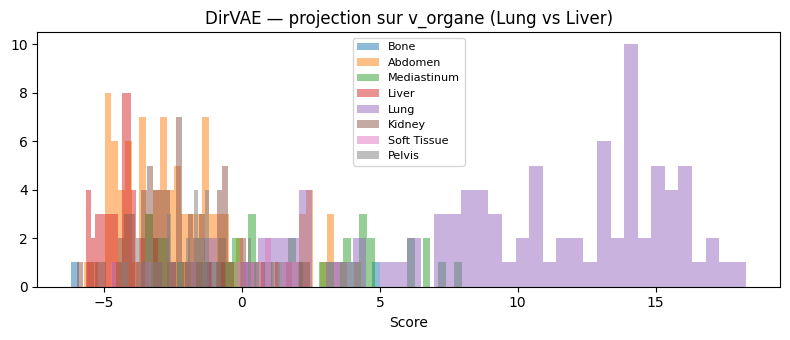


══ GVAE ══
  v_organe (Lung n=91, Liver n=59)


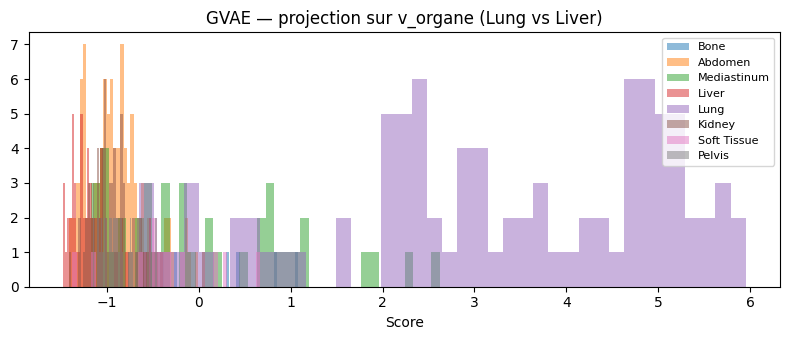

In [70]:
LUNG, LIVER = 5, 4

def class_mean_direction(latents, labels, pos, neg):
    pm, nm = labels == pos, labels == neg
    if pm.sum() < 2 or nm.sum() < 2:
        return None, pm.sum(), nm.sum()
    v = latents[pm].mean(0) - latents[nm].mean(0)
    return v / (np.linalg.norm(v) + 1e-12), pm.sum(), nm.sum()

dir_results = {}
for mname, lat in [('DirVAE', latents_dirvae), ('GVAE', latents_gvae)]:
    print(f"\n══ {mname} ══")
    d_organ, n_l, n_li = class_mean_direction(lat, organ_labels, LUNG, LIVER)
    print(f"  v_organe (Lung n={n_l}, Liver n={n_li})")
    if d_organ is not None:
        np.save(os.path.join(RESULTS_DIR, f'dir_organ_{mname.lower()}.npy'), d_organ)
        dir_results[(mname, 'organe')] = d_organ
        # Histogramme projection
        proj = lat @ d_organ
        fig, ax = plt.subplots(figsize=(8, 3.5))
        unique_organs = sorted(np.unique(organ_labels))
        for i, o in enumerate(unique_organs):
            mask = organ_labels == o
            if mask.sum() < 5: continue
            ax.hist(proj[mask], bins=40, alpha=0.5,
                    label=organ_names.get(o, str(o)),
                    color=plt.cm.tab10(i % 10))
        ax.set_title(f'{mname} — projection sur v_organe (Lung vs Liver)')
        ax.set_xlabel('Score'); ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f'projection_{mname.lower()}.png'),
                    dpi=120, bbox_inches='tight')
        plt.show()

## 12 — Latent traversal 5×5 (DirVAE et GVAE)

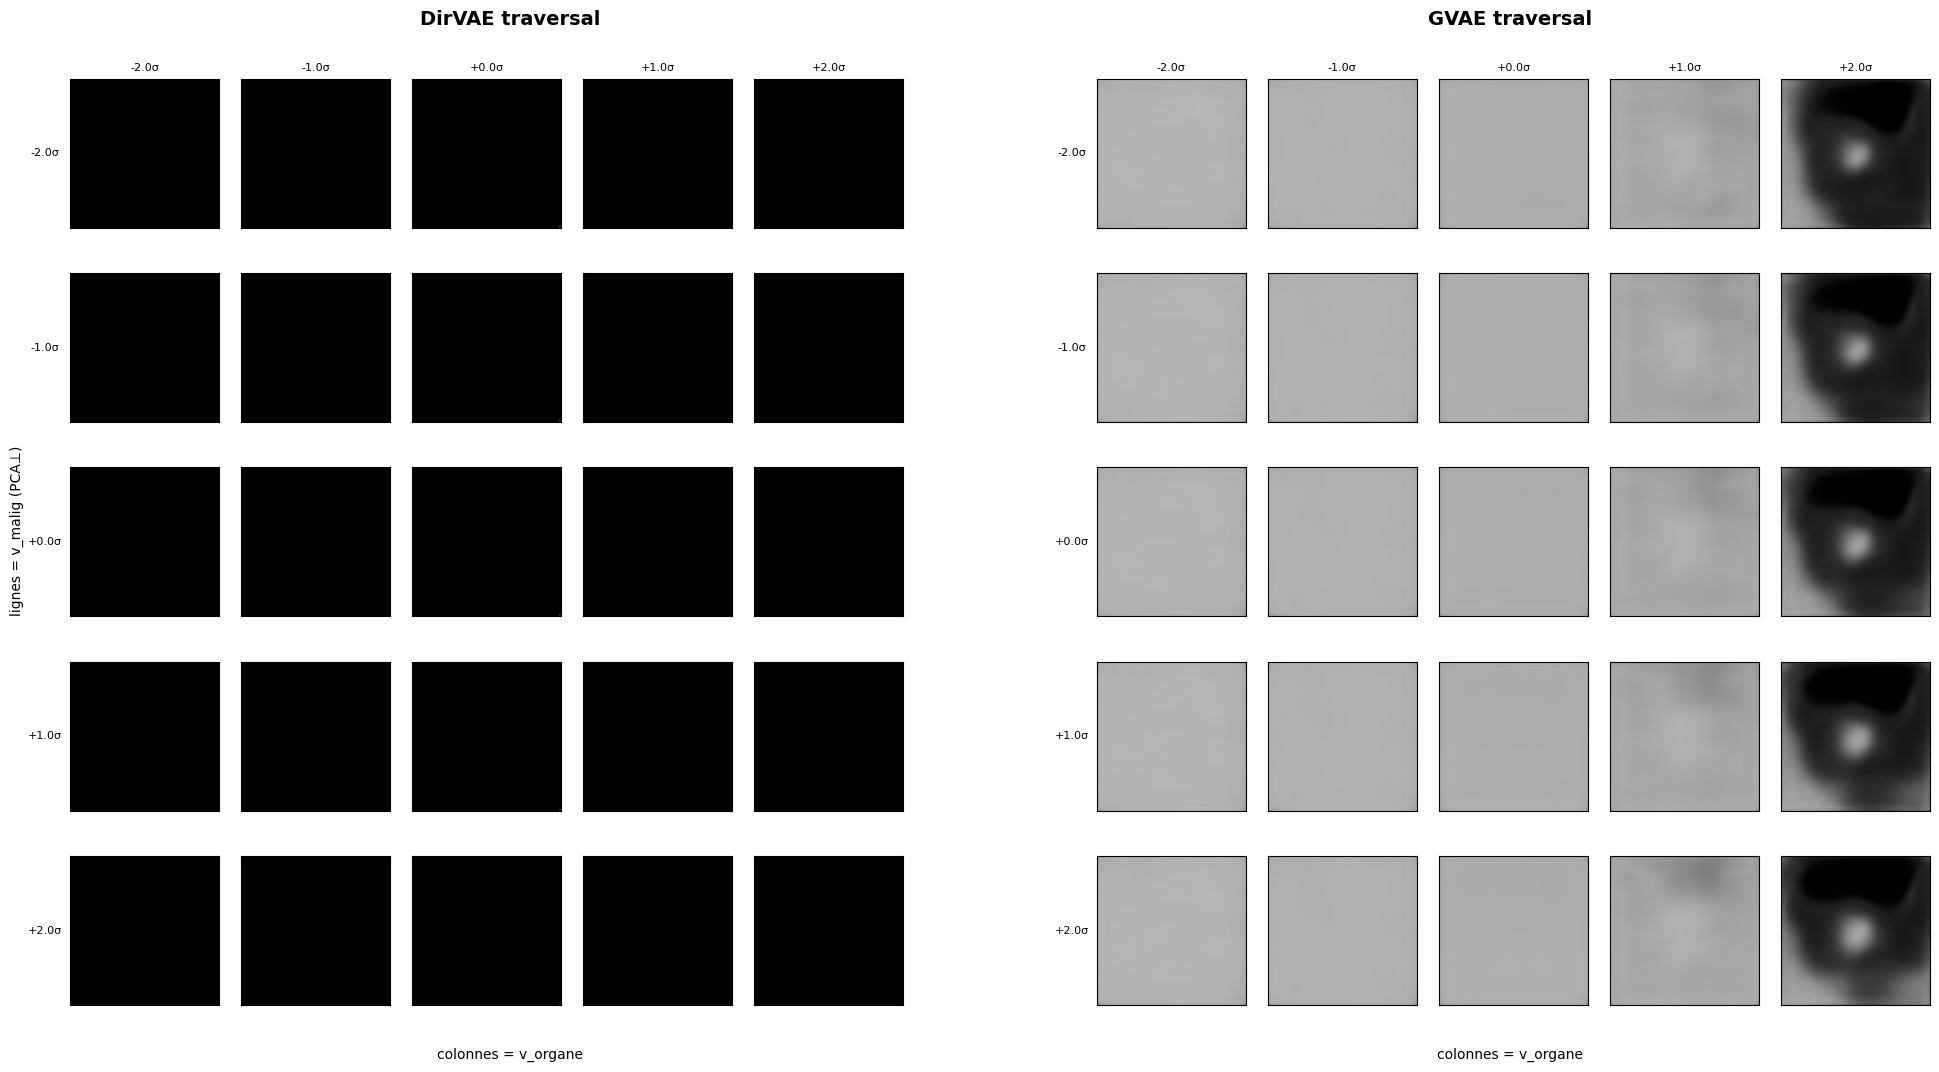

In [54]:
def make_traversal(model, model_type, dir_organ, dir_malig, latents):
    z0 = latents.mean(0)
    s_o = float((latents @ dir_organ).std())
    s_m = float((latents @ dir_malig).std())
    GRID = 5
    alphas = np.linspace(-2, 2, GRID)
    images = np.zeros((GRID, GRID, 64, 64))
    model.eval()
    with torch.no_grad():
        for i, am in enumerate(alphas):
            for j, ao in enumerate(alphas):
                z = z0 + ao * s_o * dir_organ + am * s_m * dir_malig
                z_t = torch.from_numpy(z).float().unsqueeze(0).to(device).repeat(2, 1)
                x_hat = model.decoder(z_t)
                images[i, j] = x_hat[0, 0].cpu().numpy()
    return images, alphas

# Direction malignité = PCA orthogonale à v_organe (faute de vrais labels)
from sklearn.decomposition import PCA

def get_orth_dir(latents, dir_organ):
    pc1 = PCA(n_components=2).fit(latents).components_[0]
    v = pc1 - (pc1 @ dir_organ) * dir_organ
    return v / (np.linalg.norm(v) + 1e-12)

# DirVAE
dir_malig_d = get_orth_dir(latents_dirvae, dir_results[('DirVAE', 'organe')])
img_d, alphas = make_traversal(dirvae_model, 'dirvae',
                                dir_results[('DirVAE', 'organe')], dir_malig_d,
                                latents_dirvae)

# GVAE
dir_malig_g = get_orth_dir(latents_gvae, dir_results[('GVAE', 'organe')])
img_g, _ = make_traversal(gvae_model, 'gvae',
                           dir_results[('GVAE', 'organe')], dir_malig_g,
                           latents_gvae)

# ── Affichage : 2 grilles 5×5 côte à côte ────────────────────────
fig = plt.figure(figsize=(20, 11))
GRID = 5

def plot_grid(images, alphas, fig, offset, title):
    """offset = 0 (gauche) ou 5 (droite) — on travaille en grille 5×11
       (5 cols par modèle + 1 col d'espace au milieu)."""
    NCOLS = 11
    for i in range(GRID):
        for j in range(GRID):
            ax = fig.add_subplot(GRID, NCOLS, i * NCOLS + j + 1 + offset)
            ax.imshow(images[i, j], cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0:
                ax.set_title(f"{alphas[j]:+.1f}σ", fontsize=8)
            if j == 0:
                ax.set_ylabel(f"{alphas[i]:+.1f}σ", fontsize=8,
                              rotation=0, labelpad=18, va='center')
    # Titre du modèle (au-dessus de la première ligne)
    fig.text(
        0.27 if offset == 0 else 0.77, 0.96,
        title, ha='center', fontsize=14, fontweight='bold'
    )

plot_grid(img_d, alphas, fig, offset=0, title='DirVAE traversal')
plot_grid(img_g, alphas, fig, offset=6, title='GVAE traversal')

# Légende axes
fig.text(0.27, 0.02, 'colonnes = v_organe',  ha='center', fontsize=10)
fig.text(0.77, 0.02, 'colonnes = v_organe',  ha='center', fontsize=10)
fig.text(0.02, 0.5,  'lignes = v_malig (PCA⊥)', va='center', rotation=90, fontsize=10)

plt.subplots_adjust(left=0.05, right=0.98, top=0.92, bottom=0.06,
                    wspace=0.15, hspace=0.15)
plt.savefig(os.path.join(RESULTS_DIR, 'traversal_comparison.png'),
            dpi=120, bbox_inches='tight')
plt.show()

## 13 — Tableau récap final

In [55]:
def fmt(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return '—'
    return f"{v:.4f}"

def get(df, m, f, c):
    if df is None: return np.nan
    sub = df.query(f"modèle == '{m}' and facteur == '{f}'") if 'facteur' in df.columns \
          else df.query(f"modèle == '{m}'")
    return float(sub[c].iloc[0]) if len(sub) else np.nan

def best_classix(df, m):
    sub = df.query(f"modèle == '{m}'")
    return float(sub['NMI'].max()) if 'NMI' in sub.columns and len(sub) else np.nan

rows = [
    {'Métrique': 'Recon val (↓)',
     'DirVAE': fmt(dir_history['val_recon'][-1]),
     'GVAE':   fmt(gv_history['val_recon'][-1])},
    {'Métrique': 'SSIM val (↑)',
     'DirVAE': fmt(dir_history['val_ssim'][-1]),
     'GVAE':   fmt(gv_history['val_ssim'][-1])},
    {'Métrique': 'NMI K-Means organe (↑)',
     'DirVAE': fmt(get(df_km, 'DirVAE', 'organe', 'NMI')),
     'GVAE':   fmt(get(df_km, 'GVAE',   'organe', 'NMI'))},
    {'Métrique': 'NMI CLASSIX organe (↑)',
     'DirVAE': fmt(best_classix(df_classix, 'DirVAE')),
     'GVAE':   fmt(best_classix(df_classix, 'GVAE'))},
    {'Métrique': 'MIG organe (↑)',
     'DirVAE': fmt(get(df_mig, 'DirVAE', 'organe', 'MIG')),
     'GVAE':   fmt(get(df_mig, 'GVAE',   'organe', 'MIG'))},
]

df_recap = pd.DataFrame(rows)
print("═"*60); print("  TABLEAU RÉCAP — DirVAE vs GVAE  (archi identique)"); print("═"*60)
print(df_recap.to_string(index=False))

df_recap.to_csv(os.path.join(RESULTS_DIR, 'final_recap.csv'), index=False)

with open(os.path.join(RESULTS_DIR, 'final_recap.md'), 'w') as f:
    f.write("# Récap DirVAE vs GVAE (archi identique, base=64, latent=256)\n\n")
    f.write(df_recap.to_markdown(index=False))
print(f"\n✅ Sauvegardé : final_recap.csv + final_recap.md")

════════════════════════════════════════════════════════════
  TABLEAU RÉCAP — DirVAE vs GVAE  (archi identique)
════════════════════════════════════════════════════════════
              Métrique   DirVAE     GVAE
         Recon val (↓) 186.4642 179.9051
          SSIM val (↑)   0.6651   0.6557
NMI K-Means organe (↑)   0.2816   0.3350
NMI CLASSIX organe (↑)   0.3694   0.4006
        MIG organe (↑)   0.0017   0.0169

✅ Sauvegardé : final_recap.csv + final_recap.md


## 14 — Discussion finale

In [56]:
def parse(x):
    try: return float(x)
    except: return None

higher_better = {'SSIM val (↑)', 'NMI K-Means organe (↑)',
                 'NMI CLASSIX organe (↑)', 'MIG organe (↑)'}
lower_better  = {'Recon val (↓)'}

dir_wins = gv_wins = ties = 0
for _, r in df_recap.iterrows():
    d, g = parse(r['DirVAE']), parse(r['GVAE'])
    if d is None or g is None: continue
    m = r['Métrique']
    if m in higher_better:
        if d > g: dir_wins += 1
        elif g > d: gv_wins += 1
        else: ties += 1
    elif m in lower_better:
        if d < g: dir_wins += 1
        elif g < d: gv_wins += 1
        else: ties += 1

print("═"*60); print("  VERDICT"); print("═"*60)
print(f"DirVAE gagne : {dir_wins}")
print(f"GVAE   gagne : {gv_wins}")
print(f"Égalité      : {ties}")

if dir_wins > gv_wins + 1:
    print("\n→ DirVAE domine. Le prior Dirichlet semble effectivement induire")
    print("  une structure latente plus exploitable que le prior gaussien.")
    print("  Reproduction qualitative du résultat de Keel et al.")
elif gv_wins > dir_wins + 1:
    print("\n→ GVAE est compétitif/supérieur. À cette échelle (10 epochs,")
    print("  base=64), le prior Dirichlet n'apporte pas d'avantage clair.")
    print("  Finding négatif intéressant — peut-être lié au court training")
    print("  ou à la discrétisation organe utilisée.")
else:
    print("\n→ Match nul. Aucun modèle ne domine clairement.")
    print("  Choix du prior peu impactant à cette échelle.")

print("\n" + "─"*60)
print("LIMITES :")
print("─"*60)
print("""
1. Training très court (10 epochs) — convergence non garantie.
2. Pas de cross-validation : un seul seed, scores avec haute variance.
3. Pas de vrais labels malignité (proxy 'possibly_noisy' à zéro).
4. Subset minideeplesion seulement (~32k images).
5. Pas de tuning d'hyperparams indépendant pour chaque modèle.

PERSPECTIVES :
  • Étendre à 30-60 epochs pour vraie convergence
  • Multi-seed (3-5 runs) pour intervalles de confiance
  • Ajouter le stage lung-only avec AUC malignité (Keel et al.)
  • Tuner alpha_fill et beta indépendamment pour chaque modèle
""")

════════════════════════════════════════════════════════════
  VERDICT
════════════════════════════════════════════════════════════
DirVAE gagne : 1
GVAE   gagne : 4
Égalité      : 0

→ GVAE est compétitif/supérieur. À cette échelle (10 epochs,
  base=64), le prior Dirichlet n'apporte pas d'avantage clair.
  Finding négatif intéressant — peut-être lié au court training
  ou à la discrétisation organe utilisée.

────────────────────────────────────────────────────────────
LIMITES :
────────────────────────────────────────────────────────────

1. Training très court (10 epochs) — convergence non garantie.
2. Pas de cross-validation : un seul seed, scores avec haute variance.
3. Pas de vrais labels malignité (proxy 'possibly_noisy' à zéro).
4. Subset minideeplesion seulement (~32k images).
5. Pas de tuning d'hyperparams indépendant pour chaque modèle.

PERSPECTIVES :
  • Étendre à 30-60 epochs pour vraie convergence
  • Multi-seed (3-5 runs) pour intervalles de confiance
  • Ajouter le st

═══ TEST DECODER SEUL ═══
z_sum1 : range [0.0000, 0.0309], sum=1.000
  → decoder out : [0.6122, 0.7075]  mean=0.6719

latents_dirvae stats :
  shape : (414, 256)
  range : [-0.953, 4.724]
  mean  : -0.168
  std   : 0.188
  somme par échantillon (mean) : -42.960

z_centroid (raw alpha logits) : range [-0.191, 0.171]
  → decoder out : [0.0000, 0.1655]  mean=0.0000

═══ TEST FORWARD COMPLET ═══
alpha_logits  : [-0.465, 0.775]
alpha (softplus+1e-4) : [0.487, 1.154]
z_sample : [0.0000, 0.0425], sum=1.0000
decoder out : [0.1839, 0.7128]  mean=0.6636


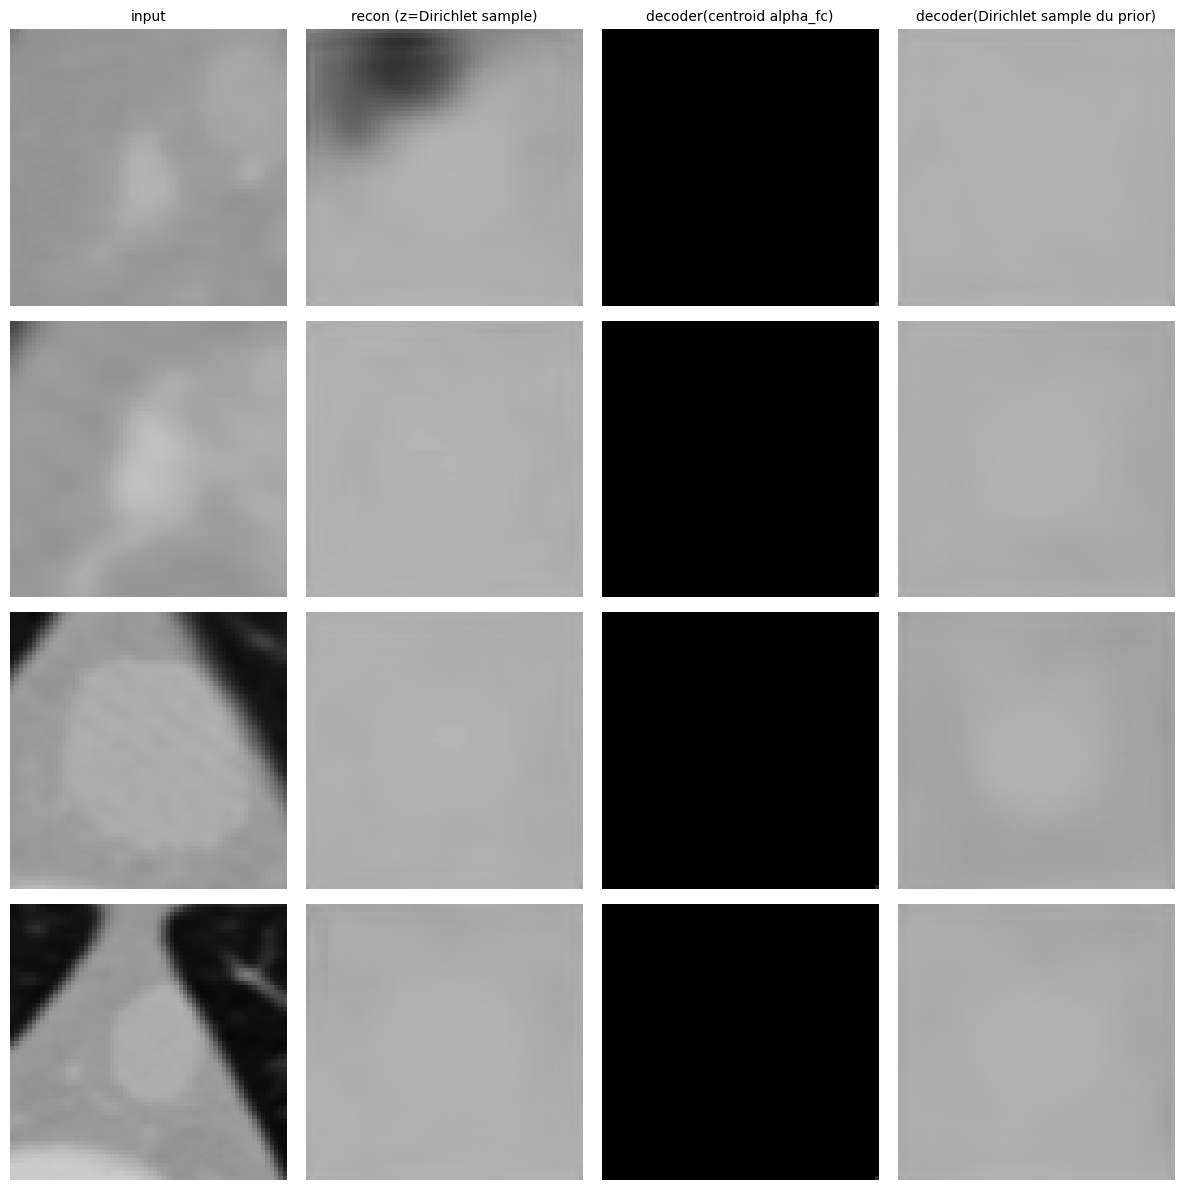

In [58]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

dirvae_model.eval()

# ── 1. Vérifier que le DECODER fonctionne ────────────────────────
print("═══ TEST DECODER SEUL ═══")

# (a) Avec des z = vraies samples Dirichlet (somme à 1)
with torch.no_grad():
    z_sum1 = torch.distributions.Dirichlet(
        torch.full((4, dirvae_model.latent_dim), 1.0)).sample().to(device)
    print(f"z_sum1 : range [{z_sum1.min():.4f}, {z_sum1.max():.4f}], "
          f"sum={z_sum1.sum(-1).mean():.3f}")
    out_sum1 = dirvae_model.decoder(z_sum1)
    print(f"  → decoder out : [{out_sum1.min():.4f}, {out_sum1.max():.4f}]  "
          f"mean={out_sum1.mean():.4f}")

# (b) Avec des z = alpha_logits passés dans le decoder (le centroïde des latents)
latents_dirvae = np.load(os.path.join(RESULTS_DIR, 'latents_dirvae.npy'))
print(f"\nlatents_dirvae stats :")
print(f"  shape : {latents_dirvae.shape}")
print(f"  range : [{latents_dirvae.min():.3f}, {latents_dirvae.max():.3f}]")
print(f"  mean  : {latents_dirvae.mean():.3f}")
print(f"  std   : {latents_dirvae.std():.3f}")
print(f"  somme par échantillon (mean) : {latents_dirvae.sum(axis=1).mean():.3f}")
# Si ces latents sont des logits (Linear sans softplus), il NE faut PAS les passer
# directement au decoder qui attend une distribution Dirichlet (somme=1, valeurs>0)

with torch.no_grad():
    z_centroid = torch.from_numpy(latents_dirvae.mean(0)).float().unsqueeze(0).to(device).repeat(4, 1)
    print(f"\nz_centroid (raw alpha logits) : "
          f"range [{z_centroid.min():.3f}, {z_centroid.max():.3f}]")
    out_centroid = dirvae_model.decoder(z_centroid)
    print(f"  → decoder out : [{out_centroid.min():.4f}, {out_centroid.max():.4f}]  "
          f"mean={out_centroid.mean():.4f}")

# ── 2. Pipeline FULL (forward de bout en bout) ───────────────────
print("\n═══ TEST FORWARD COMPLET ═══")
with torch.no_grad():
    x = next(iter(probe_loader))[:4].to(device)
    h = dirvae_model.encoder(x)
    alpha_logits = dirvae_model.alpha_fc(h)
    print(f"alpha_logits  : [{alpha_logits.min():.3f}, {alpha_logits.max():.3f}]")
    
    alpha = F.softplus(alpha_logits) + 1e-4
    print(f"alpha (softplus+1e-4) : [{alpha.min():.3f}, {alpha.max():.3f}]")
    
    z_sample = torch.distributions.Dirichlet(alpha).rsample()
    print(f"z_sample : [{z_sample.min():.4f}, {z_sample.max():.4f}], "
          f"sum={z_sample.sum(-1).mean():.4f}")
    
    out = dirvae_model.decoder(z_sample)
    print(f"decoder out : [{out.min():.4f}, {out.max():.4f}]  mean={out.mean():.4f}")

# ── 3. Visualisation comparée ────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
labels = ['input', 'recon (z=Dirichlet sample)', 'decoder(centroid alpha_fc)', 'decoder(Dirichlet sample du prior)']
for col, (imgs, lbl) in enumerate(zip([x, out, out_centroid, out_sum1], labels)):
    for row in range(4):
        axes[row, col].imshow(imgs[row, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if row == 0: axes[row, col].set_title(lbl, fontsize=10)
plt.tight_layout(); plt.show()